# **03. Baseline Model**

In [11]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sidetable
import sklearn
import feature_engine
import scipy
from scipy import stats
from pathlib import Path
import pickle

%matplotlib inline
sns.set_style('darkgrid')


In [12]:
# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [13]:
# define file path for processed data
parent_path = Path.cwd().parent
file_path = parent_path.joinpath("models", "processed.pkl")

In [14]:
# Load the processed data from the previous step
print(f"Loading processed data...")
with open(file_path, "rb") as f:
    processed_data = pickle.load(f)

Loading processed data...


In [15]:
processed_data.keys()

dict_keys(['X_train', 'y_train', 'X_test', 'test_id', 'numeric_features', 'ordinal_features', 'categorical_features', 'boolean_features', 'year_features'])

In [16]:
# Extract features and target variable
X_train = processed_data["X_train"]
y_train = processed_data["y_train"]
X_test = processed_data["X_test"]
numeric_feat = processed_data["numeric_features"]
ordinal_feat = processed_data["ordinal_features"]
categorical_feat = processed_data["categorical_features"]
boolean_feat = processed_data["boolean_features"]
year_feat = processed_data["year_features"]

In [17]:
print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")

Training data shape: (1459, 23)
Test data shape: (1457, 23)


## **1. Feature Selection**

In [18]:
# 1. Feature Selection for Linear Models
print("\n=== FEATURE SELECTION ===")

# Create dictionary to store different feature sets
feature_sets = {}


=== FEATURE SELECTION ===


**Preference 1.1. Correlation Analysis: compute correlation between numeric features and the target variable**


In [19]:
correlations = X_train[ordinal_feat + numeric_feat + year_feat + boolean_feat].corrwith(y_train).abs().sort_values(ascending=False)
print("Top correlated features with the target variable:")
print(correlations)

Top correlated features with the target variable:
LivAreaQual                0.795007
OverallQual                0.793055
TotalSF                    0.765099
NeighborhoodMedianPrice    0.720926
ExterQual                  0.684381
KitchenQual                0.660666
GarageCars                 0.640954
TotalBath                  0.633484
BsmtQual                   0.585748
HouseAge                   0.573607
QualCond                   0.565831
GarageFinish               0.549590
RemodeledAge               0.513813
GarageYrBlt                0.508240
HasFireplace               0.472022
Fireplaces                 0.466967
HasPorch                   0.413045
MasVnrArea                 0.405516
TotalPorchSF               0.337434
CentralAir                 0.251326
HasGarage                  0.236829
BsmtFinSF1                 0.185520
dtype: float64


**Prefrence 1.2. Use Ridge Regression to compute feature importance**


In [20]:
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge

# Transformes to cast boolean to int
bool_to_int = FunctionTransformer(lambda x: x.astype(int))

# Define preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numeric_feat),
        ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_feat),
        ("boolean", bool_to_int, boolean_feat),
        ("ordinal", "passthrough", ordinal_feat),
        ("year", "passthrough", year_feat)
    ]
)

# build pipeline
ridge_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("ridge", Ridge(alpha=10.0))
])
ridge_pipeline.fit(X_train, y_train)

# Extract features names after one-hot encoding
features_name = (
    numeric_feat +
    list(ridge_pipeline.named_steps['preprocessor'].named_transformers_['categorical'].get_feature_names_out(categorical_feat)) +
    boolean_feat + ordinal_feat + year_feat
) 

# Extract coefficients from the Ridge model
ridge_coef = ridge_pipeline.named_steps['ridge'].coef_

feature_importance = pd.DataFrame({
    "Feature": features_name,
    "Importance": ridge_coef
})
feature_importance.sort_values(by="Importance", ascending=False, inplace=True, ignore_index=True)
print("Top 20 features by importance from Ridge Regression:")
display(feature_importance.head(20))


Top 20 features by importance from Ridge Regression:


,Feature,Importance
0,Neighborhood_NoRidge,27612.306051
1,TotalSF,20340.434725
2,Neighborhood_StoneBr,18199.480640
3,GarageCars,15816.627446
4,Fireplaces,14545.714476
5,Neighborhood_BrkSide,13638.128931
6,NeighborhoodMedianPrice,13187.580203
7,Neighborhood_MeadowV,11110.197771
8,Neighborhood_NridgHt,10705.531313
9,Neighborhood_IDOTRR,10599.184349


In [21]:
# Feature Set 2: Top features based on Ridge importance
# Get top 20 features from ridge importance
top_ridge_features = feature_importance['Feature'][:20].tolist()

# Extract original name of features
# E.g., from "Neighborhood_Sawyer" to "Neighborhood"
original_cat_feat = set()
for f in feature_importance['Feature']:
    for cat in categorical_feat:
        if f.startswith(cat + '_'):
            original_cat_feat.add(cat)
            break

# Filter top ridge features to get numeric features, 
top_ridge_numeric = [f for f in numeric_feat if f in top_ridge_features]
top_ridge_boolean = [f for f in boolean_feat if f in top_ridge_features]
top_ridge_year = [f for f in year_feat if f in top_ridge_features]
top_ridge_ordinal = [f for f in ordinal_feat if f in top_ridge_features]

# Find top categorical features by max importance of their encoded versions
if categorical_feat:
    cat_max_importance = (
        feature_importance
        .assign(Original=feature_importance['Feature'].str.split('_').str[0])
        .groupby('Original')['Importance']
        .max()
        .loc[categorical_feat]
        .sort_values(ascending=False)
    )
    top_ridge_categorical_original = cat_max_importance.index[:5].tolist()

# Store the second feature set - handle case with no categorical features
ridge_numeric_feat = top_ridge_numeric.copy() + top_ridge_boolean.copy() + top_ridge_year.copy() + top_ridge_ordinal.copy()
if top_ridge_categorical_original:
    ridge_numeric_feat.extend(top_ridge_categorical_original)

feature_sets['ridge_selected'] = {
    'numeric_features': top_ridge_numeric,
    'boolean_features' : top_ridge_boolean,
    'ordinal_features' : top_ridge_ordinal,
    'year_features' : top_ridge_year,
    'categorical_features': top_ridge_categorical_original,
    'X_train': X_train[ridge_numeric_feat],
    'X_test': X_test[ridge_numeric_feat]
}

**Preference 1.3. Selection of Top Features Manually**


In [33]:
selected_features = [
    'LivAreaQual',              # Living area quality
    'OverallQual',              # Overall quality
    'TotalSF',                  # Total square feet
    'NeighborhoodMedianPrice',   # Neighborhood price level
    'ExterQual',                # Exterior quality
    'KitchenQual',              # Kitchen quality
    'BsmtQual',                 # Basement quality
    'GarageCars',                # Garage capacity
    'TotalBath',                # Total bathrooms
    'HouseAge',                 # House age
    'QualCond',                 # Quality and condition
    'RemodeledAge',             # Years since remodeling
    'HasFireplace',             # Has fireplace indicator
    'CentralAir',               # Central air indicator
    'GarageFinish'             # Finishing of garage
]

# Check if all selected features exist in the dataset
missing_features = [feat for feat in selected_features if feat not in X_train.columns]
if missing_features:
    print(f"Warning: These selected features are missing from the dataset: {missing_features}")
    # Remove missing features from selection
    selected_features = [feat for feat in selected_features if feat in X_train.columns]

# Categorize manual features
manual_numeric = [f for f in selected_features if f in numeric_feat]
manual_ordinal = [f for f in selected_features if f in ordinal_feat]
manual_year = [f for f in selected_features if f in year_feat]
manual_boolean = [f for f in selected_features if f in boolean_feat]
manual_categorical = [f for f in selected_features if f in categorical_feat]

# Store the third feature set
feature_sets['manual_selected'] = {
    'numeric_features': manual_numeric,
    'boolean_features': manual_boolean,
    'ordinal_features': manual_ordinal,
    'year_features': manual_year,
    'categorical_features': manual_categorical,
    'X_train': X_train[selected_features],
    'X_test': X_test[selected_features]
}

# Print summary of feature sets
for name, feature_set in feature_sets.items():
    print(f"\nFeature set: {name}")
    print(f"Number of features: {len(feature_set['numeric_features']) + len(feature_set['categorical_features']) + 
                                len(feature_set['boolean_features']) + len(feature_set['ordinal_features']) + 
                                len(feature_set['year_features'])}"
                                )
    print(f"Numeric features: {len(feature_set['numeric_features'])}")
    print(f"Boolean features: {len(feature_set['boolean_features'])}")
    print(f"Ordinal features: {len(feature_set['ordinal_features'])}")
    print(f"Year features: {len(feature_set['year_features'])}")
    print(f"Categorical features: {len(feature_set['categorical_features'])}")


Feature set: ridge_selected
Number of features: 13
Numeric features: 5
Boolean features: 0
Ordinal features: 7
Year features: 0
Categorical features: 1

Feature set: manual_selected
Number of features: 15
Numeric features: 6
Boolean features: 2
Ordinal features: 7
Year features: 0
Categorical features: 0


## **2. Processing Pipeline**

This pipeline ensumers that both training and test datasets undergo identical preprocessing.

- It fills in missing numeric values using the median.

- It standardizes numeric features so they have a mean of 0 and a standard deviation of 1, which helps regression models train more efficiently.

- It addresses missing categorical values by substituting the most frequent category.

- It converts categorical variables into numerical form through one-hot encoding.

- It keeps year and ordinal features as they are, passing them through without transformation.

- It converts boolean features into numeric values using a FunctionTransformer.

- It produces a unified(single) transformer that can be applied consistently to new data during prediction.

By automating these steps, the pipeline avoids data leakage and ensures that test data is processed using statistics derived solely from the training set — a more reliable approach than manual preprocessing.

In [34]:
from sklearn.impute import SimpleImputer
preprocessing_pipelines = {}

for name, feature_set in feature_sets.items():
    # For numeric features: impute and scale
    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    # For categorical features: impute and one-hot encoding
    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy='most_frequent')),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])

    # For boolean features: convert into integer
    # Transformes to cast boolean to int
    bool_to_int = FunctionTransformer(lambda x: x.astype(int))
    boolean_transformer = Pipeline(steps=[
        ("bool", bool_to_int)
    ])

    # For year and ordinal features: use them as raw
    year_transformer = Pipeline(steps=[
        ("passthrough", "passthrough")
    ])

    ordinal_transformer = Pipeline(steps=[
        ("passthrough", "passthrough")
    ])

    # Combining processing steps
    transformers = [("numeric", numeric_transformer, feature_set['numeric_features']),
                    ("boolean", boolean_transformer, feature_set['boolean_features']),
                    ("ordinal", ordinal_transformer, feature_set['ordinal_features']),
                    ("year", year_transformer, feature_set['year_features'])

    ]

    # Add categorical transformer if there is categorical feature:
    if len(feature_set['categorical_features']) > 0:
        transformers.append(("categorical", categorical_transformer, feature_set['categorical_features']))
    
    preprocessor = ColumnTransformer(transformers=transformers)

    preprocessing_pipelines[name] = preprocessor


## **3. Train-Validation Split for each feature set**

This split creates a validation set that allows the model to be tested on data it hasn’t seen before. By allocating 80% of the dataset for training and reserving 20% for validation, you can:

- Train the model on a large portion of the available data.

- Evaluate its performance on unseen examples.

- Obtain a more reliable estimate of how it will generalize to new houses.

Using random_state=42 ensures the split is reproducible, so you’ll get the same training and validation sets every time the code runs.

In [43]:
from sklearn.model_selection import train_test_split
train_val_splits = {}

for name, feature_set in feature_sets.items():

    X_train_set = feature_set['X_train']
    X_train_main, X_val, y_train_main, y_val = train_test_split(
        X_train_set,
        y_train,
        test_size=0.20,
        random_state=42
    )

    train_val_splits[name] = {
        "X_train_main" : X_train_main,
        "X_val" : X_val,
        "y_train_main" : y_train_main,
        "y_val" : y_val,
        "X_train_full" : X_train_set,
        "X_test" : feature_set['X_test']
    }

    print(f"\nFeature Set: {name}")
    print(f"Training subset shape : {X_train_main.shape}")
    print(f"Validation subset shape : {X_val.shape}")




Feature Set: ridge_selected
Training subset shape : (1167, 13)
Validation subset shape : (292, 13)

Feature Set: manual_selected
Training subset shape : (1167, 15)
Validation subset shape : (292, 15)


## **4. Defining Baseline Models**


This dictionary outlines several regression models to experiment with:

**Linear Regression**: 

- In linear regression, we try to minimize:

$J(\theta) = \frac{1}{2m} \sum_{i=1}^{m} \big(h_\theta(x^{(i)}) - y^{(i)}\big)^2$

- Serves as the baseline model without any regularization.

**Ridge Regression**: 

- In the regularized linear regression (Ridge), we try to minimize:

$J(\theta) = \frac{1}{2m}\sum_{i=1}^{m}(h_\theta(x^{(i)}) - y^{(i)})^2 + \frac{\alpha}{2m}\sum_{j=1}^{n}\theta_j^2$

where  ${\alpha}$
is a regularization parameter which controls the degree of regularization (thus, help preventing overfitting). The regularization term puts a penalty on the overall cost J. As the magnitudes of the model parameters ${\theta_j}$
increase, the penalty increases as well.

I will find the ${\alpha}$
that gives me the smallest RMSLE from cross-validation:

- Applies L2 regularization, discouraging overly large coefficients to reduce overfitting. Multiple alpha values are tested to explore different penalty strengths.


**Lasso Regression**: 

- Lasso Regression is very similar to Ridge regression. One difference is that in the regularization term, instead of using sum of squared of ${\theta}$, we use sum of absolute value of  $\theta$:

$J(\theta)=\frac{1}{2m}\sum_{i=1}^{m}(h_\theta(x^{(i)})-y^{(i)})^2+\frac{\alpha}{2m}\sum_{j=1}^{n}|\theta_j|$

Another big difference is that Ridge Regresion can only shrink parameters close to zero while Lasso Regression can shrink some parameters all the way to 0. Therefore, we can use Lasso Regression to perform feature selection and regression.


- Uses L1 regularization, which can shrink some coefficients to zero, effectively performing feature selection. Multiple alpha values are evaluated here as well.

**ElasticNet**: 

- Elastic Net Regression combines the strengths of both Ridge and Lasso. Its regularization term is a mix of the L1 penalty (absolute values of $\theta$) and the L2 penalty (squared values of $\theta$):
Elastic Net cost function:

$J(\theta) = \frac{1}{2m} \sum_{i=1}^{m} \big(h_\theta(x^{(i)}) - y^{(i)}\big)^2 + \frac{\alpha}{2m} \left( \rho \sum_{j=1}^{n} |\theta_j| + (1 - \rho) \sum{j=1}^{n} \theta_j^2 \right)$

Here, $\rho$ controls the balance between L1 and L2 regularization.

- Like Ridge, it shrinks coefficients to prevent overfitting.

- Like Lasso, it can drive some coefficients exactly to zero, enabling feature selection.

- By blending both, Elastic Net is especially useful when features are highly correlated, offering more stability than Lasso alone.

- Combines both L1 and L2 regularization, balancing feature selection with coefficient shrinkage.

By testing a range of models and varying alpha values, you can determine which approach best fits the data and provides the most reliable performance.

In [74]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

models = {
    "Linear Regression" : LinearRegression(),
    "Ridge Regression (alpha=1.0)" : Ridge(alpha=1.0, max_iter=10000),
    "Ridge Regression (alpha=10.0)" : Ridge(alpha=10.0, max_iter=10000),
    "Ridge Regression (alpha=100.0)" : Ridge(alpha=100.0, max_iter=10000),
    "Lasso Regression (alpha=0.001)" : Lasso(alpha=0.0001, max_iter=10000),
    "Lasso Regression (alpha=0.01)" : Lasso(alpha=0.001, max_iter=10000),
    "Lasso Regression (alpha=0.1)" : Lasso(alpha=0.01, max_iter=10000),
    'ElasticNet (alpha=0.01, l1_ratio=0.5)': ElasticNet(alpha=0.001, l1_ratio=0.05, max_iter=10000)
}

## **5. Baseline Models**

- Tests each model with proper preprocessing 

- Evaluate performance of a validation set using several metrics:

    - **RMSE (Root Mean Squared Error)**: Highlights large errors more strongly.

    - **MAE (Mean Absolute Error)**: Provides a measure that is less sensitive to outliers.

    - **$R^2$ (Coefficient of Determination)**: Indicates the proportion of variance explained by the model.

- Performs 5-fold cross-validation for a more robust performance estimate.

- Store all results for comparison.

Cross-validation is particularly important as it gives a more stable estimate of model performance by training and testing on different subsets of the data.

In [75]:
# 5. Baseline Models
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold, cross_val_score

all_results = {}
for feature_set_name, feature_set_data in train_val_splits.items():
    print(f"\n======= Baseline for feature set : {feature_set_name} ======")

    results = {}
    X_train_main = feature_set_data['X_train_main']
    X_val = feature_set_data['X_val']
    y_train_main = feature_set_data['y_train_main']
    y_val = feature_set_data['y_val']
    X_train_full = feature_set_data['X_train_full']
    X_test_full = feature_set_data['X_test']

    for name, model in models.items():
        print(f"\nEvaluating : {name}")
        
        # Create pipeline with preprocessing and models
        pipeline = Pipeline(steps=[
            ('preprocessor', preprocessing_pipelines[feature_set_name]),
            ('model', model)
        ])

        # Fit on training dataset
        pipeline.fit(X_train_main, y_train_main)

        # Evaluate on validation dataset
        val_pred = pipeline.predict(X_val)
        val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
        val_mae = mean_absolute_error(y_val, val_pred)
        val_r2 = r2_score(y_val, val_pred)

        print(f" - Validation RMSE : ${val_rmse:.2f}")
        print(f" - Validate MAE : ${val_mae:.2f}")
        print(f" - Validation 'R\u00B2' {val_r2:.4f}")

        # Evaluate with cross-validation
        kf = KFold(n_splits=5, shuffle=True, random_state=42)
        cv_scores = cross_val_score(
            pipeline,
            X_train_full,
            y_train,
            cv=kf,
            scoring='neg_root_mean_squared_error'

        )

        cv_rmse = -cv_scores.mean()
        cv_std = cv_scores.std()

        print(f" - 5-Fold CV RMSE : ${cv_rmse:.2f} (±${cv_std:.2f})")

        # Store results 
        results[name] ={
            'val_rmse' : val_rmse,
            'val_mae' : val_mae,
            'val_r2' : val_r2,
            'cv_rmse' : cv_rmse,
            'cv_std' : cv_std,
            'pipeline' : pipeline
        }

    all_results[feature_set_name] = results



======= Baseline for feature set : ridge_selected ======

Evaluating : Linear Regression
 - Validation RMSE : $30307.51
 - Validate MAE : $21706.88
 - Validation 'R²' 0.8475
 - 5-Fold CV RMSE : $34239.34 (±$2847.93)

Evaluating : Ridge Regression (alpha=1.0)
 - Validation RMSE : $30259.57
 - Validate MAE : $21658.50
 - Validation 'R²' 0.8480
 - 5-Fold CV RMSE : $34221.11 (±$2855.66)

Evaluating : Ridge Regression (alpha=10.0)
 - Validation RMSE : $30041.93
 - Validate MAE : $21481.69
 - Validation 'R²' 0.8502
 - 5-Fold CV RMSE : $34221.07 (±$2936.18)

Evaluating : Ridge Regression (alpha=100.0)
 - Validation RMSE : $30439.02
 - Validate MAE : $21785.84
 - Validation 'R²' 0.8462
 - 5-Fold CV RMSE : $34904.15 (±$3072.26)

Evaluating : Lasso Regression (alpha=0.001)


c:\Users\Admin\anaconda3\envs\test_titanic\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.291e+11, tolerance: 7.448e+08
  model = cd_fast.enet_coordinate_descent(


 - Validation RMSE : $30307.51
 - Validate MAE : $21706.88
 - Validation 'R²' 0.8475


c:\Users\Admin\anaconda3\envs\test_titanic\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.291e+11, tolerance: 7.448e+08
  model = cd_fast.enet_coordinate_descent(
c:\Users\Admin\anaconda3\envs\test_titanic\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.801e+11, tolerance: 7.322e+08
  model = cd_fast.enet_coordinate_descent(
c:\Users\Admin\anaconda3\envs\test_titanic\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider incre

 - 5-Fold CV RMSE : $34239.34 (±$2847.93)

Evaluating : Lasso Regression (alpha=0.01)


c:\Users\Admin\anaconda3\envs\test_titanic\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.291e+11, tolerance: 7.448e+08
  model = cd_fast.enet_coordinate_descent(


 - Validation RMSE : $30307.50
 - Validate MAE : $21706.88
 - Validation 'R²' 0.8475


c:\Users\Admin\anaconda3\envs\test_titanic\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.291e+11, tolerance: 7.448e+08
  model = cd_fast.enet_coordinate_descent(
c:\Users\Admin\anaconda3\envs\test_titanic\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.801e+11, tolerance: 7.322e+08
  model = cd_fast.enet_coordinate_descent(
c:\Users\Admin\anaconda3\envs\test_titanic\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider incre

 - 5-Fold CV RMSE : $34239.34 (±$2847.93)

Evaluating : Lasso Regression (alpha=0.1)


c:\Users\Admin\anaconda3\envs\test_titanic\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.291e+11, tolerance: 7.448e+08
  model = cd_fast.enet_coordinate_descent(


 - Validation RMSE : $30307.44
 - Validate MAE : $21706.82
 - Validation 'R²' 0.8475


c:\Users\Admin\anaconda3\envs\test_titanic\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.291e+11, tolerance: 7.448e+08
  model = cd_fast.enet_coordinate_descent(
c:\Users\Admin\anaconda3\envs\test_titanic\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.801e+11, tolerance: 7.322e+08
  model = cd_fast.enet_coordinate_descent(
c:\Users\Admin\anaconda3\envs\test_titanic\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider incre

 - 5-Fold CV RMSE : $34239.33 (±$2847.96)

Evaluating : ElasticNet (alpha=0.01, l1_ratio=0.5)
 - Validation RMSE : $30254.48
 - Validate MAE : $21653.18
 - Validation 'R²' 0.8481
 - 5-Fold CV RMSE : $34219.67 (±$2856.88)

======= Baseline for feature set : manual_selected ======

Evaluating : Linear Regression
 - Validation RMSE : $31632.08
 - Validate MAE : $23105.22
 - Validation 'R²' 0.8339
 - 5-Fold CV RMSE : $36057.22 (±$2888.47)

Evaluating : Ridge Regression (alpha=1.0)
 - Validation RMSE : $31632.19
 - Validate MAE : $23104.77
 - Validation 'R²' 0.8339
 - 5-Fold CV RMSE : $36054.92 (±$2886.24)

Evaluating : Ridge Regression (alpha=10.0)
 - Validation RMSE : $31637.74
 - Validate MAE : $23115.66
 - Validation 'R²' 0.8338
 - 5-Fold CV RMSE : $36045.37 (±$2871.55)

Evaluating : Ridge Regression (alpha=100.0)
 - Validation RMSE : $31725.55
 - Validate MAE : $23230.40
 - Validation 'R²' 0.8329
 - 5-Fold CV RMSE : $36214.61 (±$2899.31)

Evaluating : Lasso Regression (alpha=0.001)
 - 

## **6. Summary : Best Model Selection**

In [ ]:
print("\n ====== Overall Results ======")

# Create a dataframe for CV RMSE across all feature set, models and its evaluating metrics
summary_df = []

for feature_set, results in all_results.items():
    for model_name, metrics in results.items():
        summary_df.append({
            'feature_set' : feature_set,
            'model' : model_name,
            'cv_rmse' : metrics['cv_rmse'],
            'cv_std' : metrics['cv_std'],
            'validation_rmse' : metrics['val_rmse'],
            'validation_mae' : metrics['val_mae'],
            'validation_r2' : metrics['val_r2']
        })

summary_data = pd.DataFrame(summary_df)

# Display and sort values by CV RMSE
print("\nAll models ranked by Cross-Validation RMSE:")
ranked_models = summary_data.sort_values('cv_rmse', ignore_index=True)
display(ranked_models[['feature_set', 'model', 'cv_rmse', 'validation_rmse', 'validation_r2']])

# Find the overall best model
best_model_row = ranked_models.iloc[0]
best_feature_set = best_model_row['feature_set']
best_model_name = best_model_row['model']
best_model = results[best_model_name]['pipeline']

print(f"\nBEST MODEL OVERALL:")
print(f"Feature Set: {best_feature_set}")
print(f"Model: {best_model_name}")
print(f"CV RMSE: ${best_model_row['cv_rmse']:.2f}")
print(f"Validation RMSE: ${best_model_row['validation_rmse']:.2f}")
print(f"Validation R²: {best_model_row['validation_r2']:.4f}")



 ====== Overall Results ======

All models ranked by Cross-Validation RMSE:


,feature_set,model,cv_rmse,validation_rmse,validation_r2
0,ridge_selected,"ElasticNet (alpha=0.01, l1_ratio=0.5)",34219.673597,30254.479131,0.848058
1,ridge_selected,Ridge Regression (alpha=10.0),34221.071971,30041.931696,0.850185
2,ridge_selected,Ridge Regression (alpha=1.0),34221.114519,30259.574672,0.848006
3,ridge_selected,Lasso Regression (alpha=0.1),34239.330760,30307.440427,0.847525
4,ridge_selected,Lasso Regression (alpha=0.01),34239.342500,30307.504692,0.847524
5,ridge_selected,Lasso Regression (alpha=0.001),34239.343675,30307.511120,0.847524
6,ridge_selected,Linear Regression,34239.343806,30307.511834,0.847524
7,ridge_selected,Ridge Regression (alpha=100.0),34904.154846,30439.015925,0.846198
8,manual_selected,Ridge Regression (alpha=10.0),36045.365273,31637.737730,0.833846
9,manual_selected,"ElasticNet (alpha=0.01, l1_ratio=0.5)",36054.689306,31632.215484,0.833904



BEST MODEL OVERALL:
Feature Set: ridge_selected
Model: ElasticNet (alpha=0.01, l1_ratio=0.5)
CV RMSE: $34219.67
Validation RMSE: $30254.48
Validation R²: 0.8481


In [100]:
best_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('boolean', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tr

## **7. Visualization : Model Comparison**

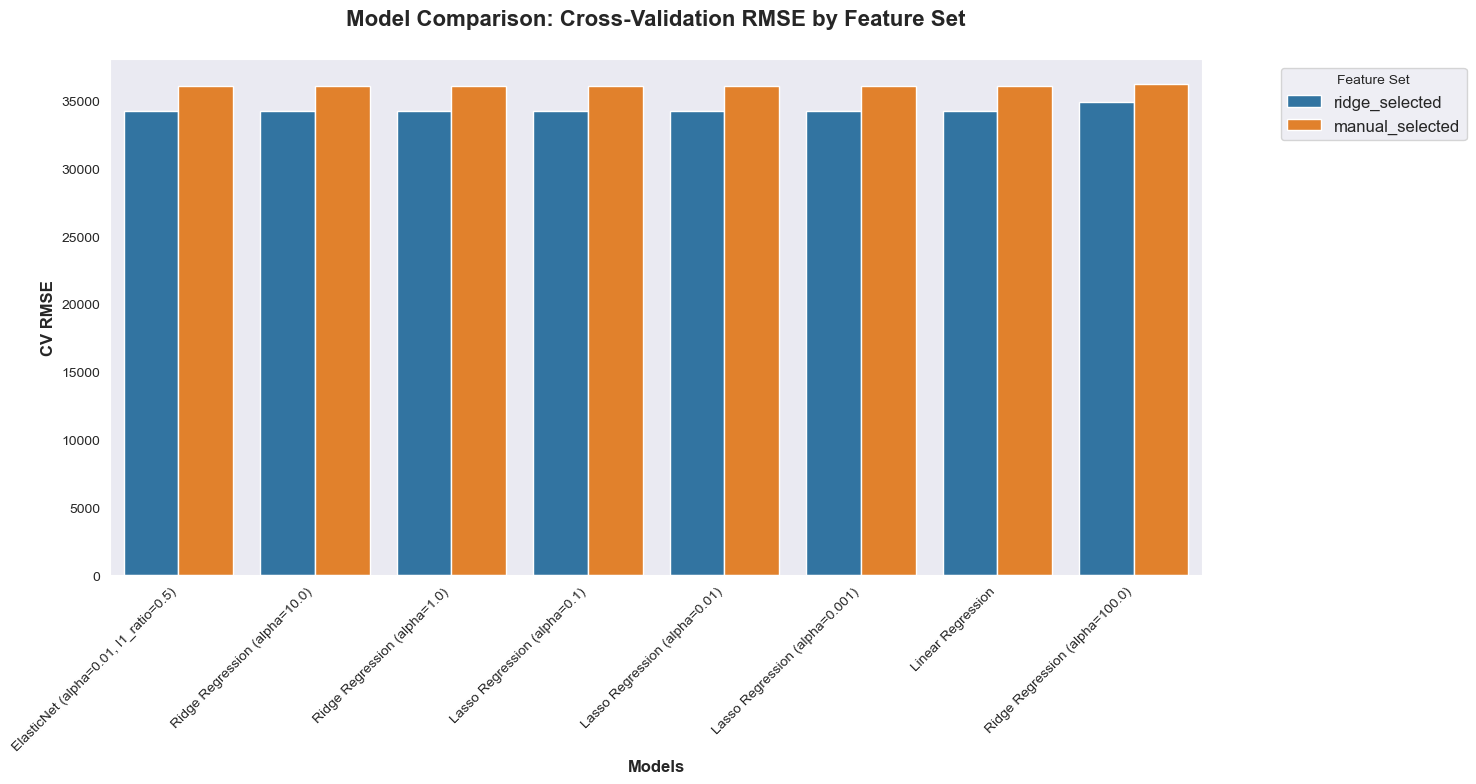

In [89]:
plt.figure(figsize=(15, 8))
sns.barplot(x='model', y='cv_rmse', hue='feature_set', data=ranked_models)
plt.xticks(rotation=45, ha='right')
plt.xlabel("Models", fontsize=12, fontweight='bold')
plt.ylabel("CV RMSE", fontsize=12, fontweight='bold')
plt.title('Model Comparison: Cross-Validation RMSE by Feature Set', fontsize=16, fontweight='bold', y=1.05)
plt.legend(title='Feature Set', fontsize=12, loc='upper right', bbox_to_anchor=(1.25, 1), frameon=True)

plt.tight_layout()
plt.grid(False)
plt.show()

## **8. Feature Importance Analysis : Best Model**

## **9. Best Model Prediction : Visualization**

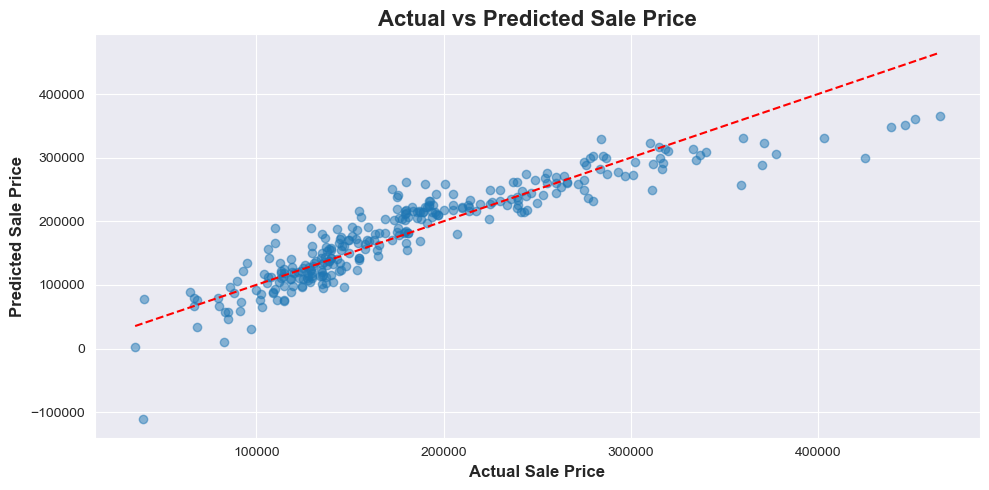

In [101]:
# Get prediction of validation set
val_pred = best_model.predict(X_val)
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(y_val, val_pred, alpha=0.5)
ax.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
ax.set_xlabel('Actual Sale Price', fontsize=12, fontweight='bold')
ax.set_ylabel('Predicted Sale Price', fontsize=12, fontweight='bold')
ax.set_title('Actual vs Predicted Sale Price', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

## **10. Checking residuals**

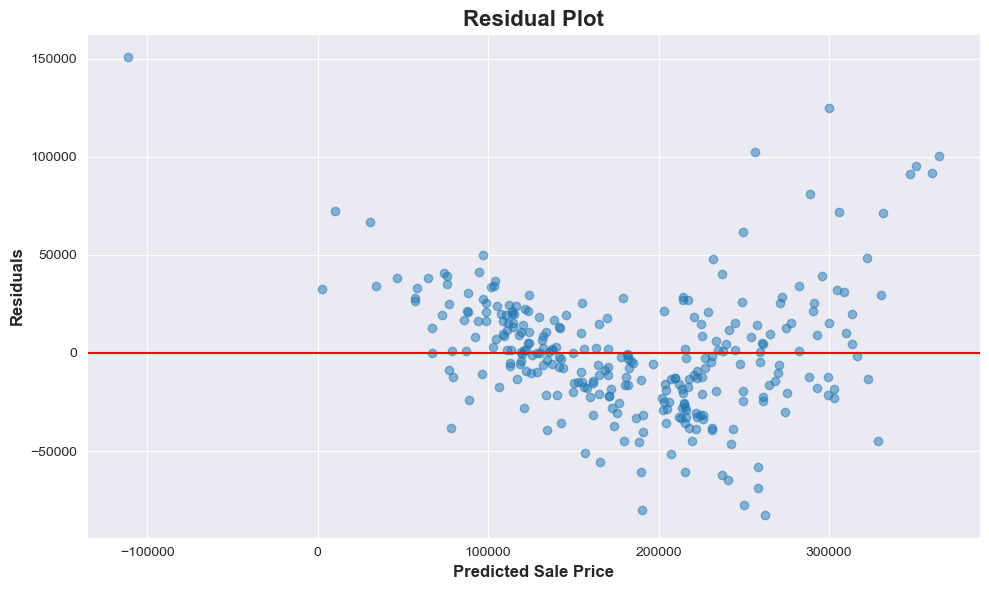

In [102]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(val_pred, y_val - val_pred, alpha=0.5)
ax.axhline(y=0, color='r', linestyle='-')
ax.set_xlabel('Predicted Sale Price', fontsize=12, fontweight='bold')
ax.set_ylabel('Residuals', fontsize=12, fontweight='bold')
ax.set_title('Residual Plot', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

## **11. Generate predictions on test set**

## **12. Save the best model**